In [384]:
!git clone https://bitbucket.org/jadslim/german-traffic-signs

fatal: destination path 'german-traffic-signs' already exists and is not an empty directory.


In [385]:
!ls german-traffic-signs

signnames.csv  test.p  train.p	valid.p


In [386]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, Input
from keras.layers import Flatten, Dropout
from keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D
import random
import pickle
import pandas as pd
import cv2
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [387]:
from keras.callbacks import LearningRateScheduler, ModelCheckpoint

%matplotlib inline
np.random.seed(0)

In [388]:
#: Implement load the data here.
with open('german-traffic-signs/train.p', 'rb') as f:
    train_data = pickle.load(f)
with open('german-traffic-signs/valid.p', 'rb') as f:
    val_data = pickle.load(f)
#: Load test data
with open('german-traffic-signs/test.p', 'rb') as f:
    test_data = pickle.load(f)

In [389]:
# Split out features and labels
X_train, y_train = train_data['features'], train_data['labels']
X_val, y_val = val_data['features'], val_data['labels']
X_test, y_test = test_data['features'], test_data['labels']

In [390]:
#already 4 dimensional
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(34799, 32, 32, 3)
(12630, 32, 32, 3)
(4410, 32, 32, 3)


In [391]:
# STOP: Do not change the tests below. Your implementation should pass these tests.
assert(X_train.shape[0] == y_train.shape[0]), "The number of images is not equal to the number of labels."
assert(X_train.shape[1:] == (32,32,3)), "The dimensions of the images are not 32 x 32 x 3."
assert(X_val.shape[0] == y_val.shape[0]), "The number of images is not equal to the number of labels."
assert(X_val.shape[1:] == (32,32,3)), "The dimensions of the images are not 32 x 32 x 3."
assert(X_test.shape[0] == y_test.shape[0]), "The number of images is not equal to the number of labels."
assert(X_test.shape[1:] == (32,32,3)), "The dimensions of the images are not 32 x 32 x 3."

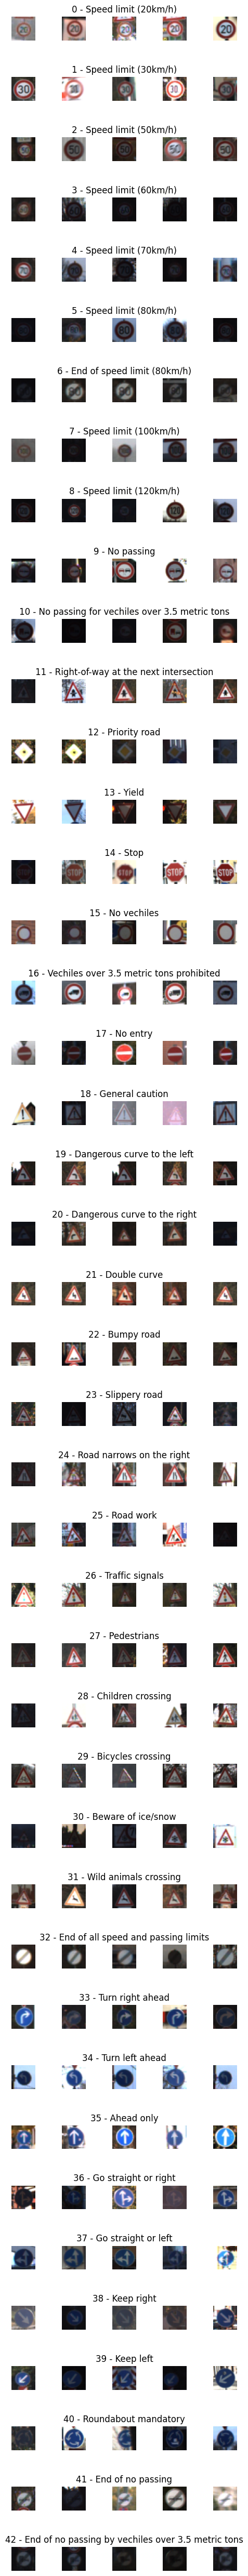

In [392]:
data = pd.read_csv('german-traffic-signs/signnames.csv')

num_of_samples = []

cols = 5
num_classes = 43

fig, axs = plt.subplots(
    nrows=num_classes,
    ncols=cols,
    figsize=(5, 50)
)
fig.tight_layout()

for i in range(cols):
    for j, row in data.iterrows():
        x_selected = X_train[y_train == j]

        axs[j][i].imshow(
            x_selected[random.randint(0, len(x_selected) - 1), :, :],
            cmap=plt.get_cmap('gray')
        )
        axs[j][i].axis("off")

        if i == 2:
            axs[j][i].set_title(
                str(j) + " - " + row["SignName"]
            )
            num_of_samples.append(len(x_selected))

[180, 1980, 2010, 1260, 1770, 1650, 360, 1290, 1260, 1320, 1800, 1170, 1890, 1920, 690, 540, 360, 990, 1080, 180, 300, 270, 330, 450, 240, 1350, 540, 210, 480, 240, 390, 690, 210, 599, 360, 1080, 330, 180, 1860, 270, 300, 210, 210]


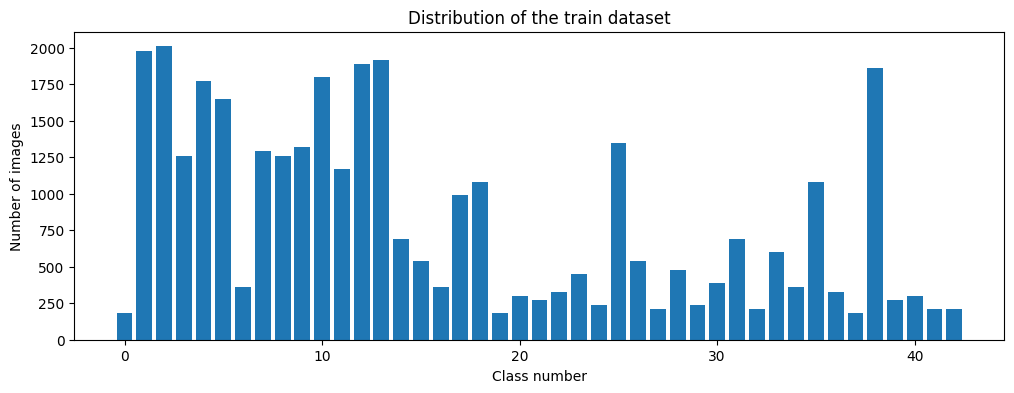

In [393]:
print(num_of_samples)

plt.figure(figsize=(12, 4))
plt.bar(range(0, num_classes), num_of_samples)
plt.title("Distribution of the train dataset")
plt.xlabel("Class number")
plt.ylabel("Number of images")
plt.show()

(32, 32, 3)
36


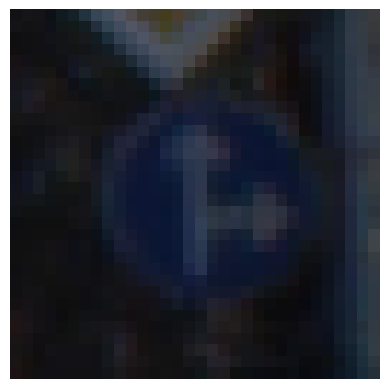

In [394]:
import cv2

plt.imshow(X_train[1000])
plt.axis("off")
print(X_train[1000].shape)
print(y_train[1000])

(32, 32)


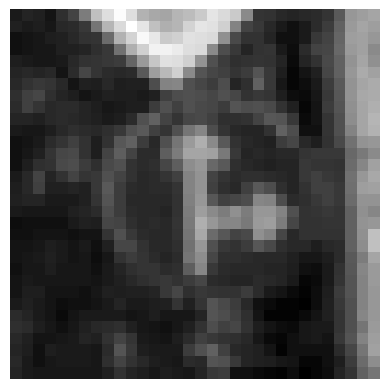

In [395]:
# preprocess of image to grascale
def grayscale(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img
img = grayscale(X_train[1000])
plt.imshow(img, cmap='gray')
plt.axis("off")
print(img.shape)

(32, 32)


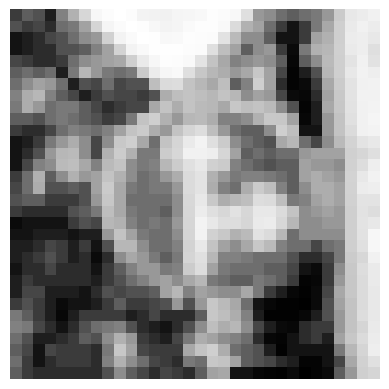

In [396]:
#preprocess image with histogram equalization
def equalize(img):
    img = cv2.equalizeHist(img)
    return img
img = equalize(img)
plt.imshow(img, cmap='gray')
plt.axis("off")
print(img.shape)

In [397]:
def preprocess(img):
    img = grayscale(img)
    img = equalize(img)
    img = img/255
    return img

X_train = np.array(list(map(preprocess, X_train)))
X_test = np.array(list(map(preprocess, X_test)))
X_val = np.array(list(map(preprocess, X_val)))

(34799, 32, 32)


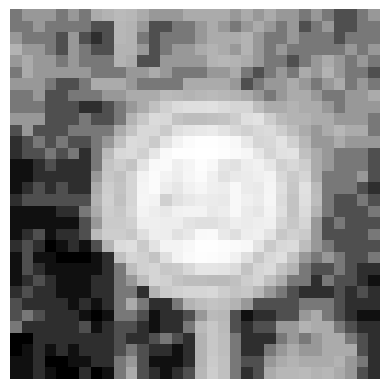

In [398]:
plt.imshow(X_train[random.randint(0, len(X_train) - 1)], cmap='gray')
plt.axis('off')
print(X_train.shape)

In [399]:
# Add a channel dimension to grayscale images: (H, W) -> (H, W, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]
X_val   = X_val[..., np.newaxis]

(15, 32, 32, 1)


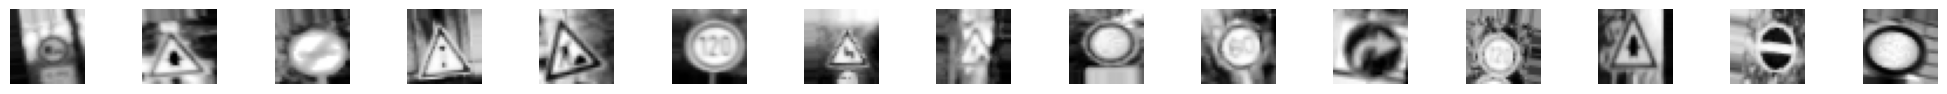

In [400]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(width_shift_range=0.1,
                            height_shift_range=0.1,
                            zoom_range=0.2,
                            shear_range=0.1,
                            rotation_range=10.)

datagen.fit(X_train)
# for X_batch, y_batch in

batches = datagen.flow(X_train, y_train, batch_size = 15)
X_batch, y_batch = next(batches)

fig, axs = plt.subplots(1, 15, figsize=(20, 5))
fig.tight_layout()

for i in range(15):
    axs[i].imshow(X_batch[i].squeeze(), cmap='gray')
    axs[i].axis("off")

print(X_batch.shape)

In [401]:
# one-hot the label
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)
y_val = to_categorical(y_val, 43)
# create model

def modified_model():
  model = Sequential()
  model.add(Input(shape=(32, 32, 1)))
  model.add(Conv2D(60, (5, 5), activation='relu'))
  model.add(Conv2D(60, (5, 5), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(30, (3, 3), activation='relu'))
  model.add(Conv2D(30, (3, 3), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Flatten())
  model.add(Dense(500, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(43, activation='softmax'))

  model.compile(Adam(learning_rate= 0.001), loss='categorical_crossentropy', metrics=['accuracy'])
  return model
model = modified_model()
print(model.summary())

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_68 (Conv2D)              │ (None, 28, 28, 60)     │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 24, 24, 60)     │        90,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 12, 12, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 10, 10, 30)     │        16,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 8, 8, 30)       │         8,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 4, 4, 30)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 500)            │       240,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 43)             │        21,543 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 378,023 (1.44 MB)

 Trainable params: 378,023 (1.44 MB)

 Non-trainable params: 0 (0.00 B)

None


In [402]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=50),
                            # steps_per_epoch=len(X_train) // 50,
                            epochs=10,
                            validation_data=(X_val, y_val), shuffle = 1)

Epoch 1/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.5181 - loss: 1.6969 - val_accuracy: 0.9197 - val_loss: 0.2552
Epoch 2/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8585 - loss: 0.4640 - val_accuracy: 0.9732 - val_loss: 0.0911
Epoch 3/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9100 - loss: 0.2880 - val_accuracy: 0.9707 - val_loss: 0.1035
Epoch 4/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9304 - loss: 0.2235 - val_accuracy: 0.9787 - val_loss: 0.0618
Epoch 5/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9439 - loss: 0.1808 - val_accuracy: 0.9832 - val_loss: 0.0530
Epoch 6/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9508 - loss: 0.1584 - val_accuracy: 0.9871 - val_loss: 0.0467
Epoch 7/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9561 - loss: 0.1392 - val_accuracy: 0.9857 - val_loss: 0.0505
Epoch 8/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9638 - loss: 0.1199 - 

Test score: 0.13328078389167786
Test accuracy: 0.9693586826324463


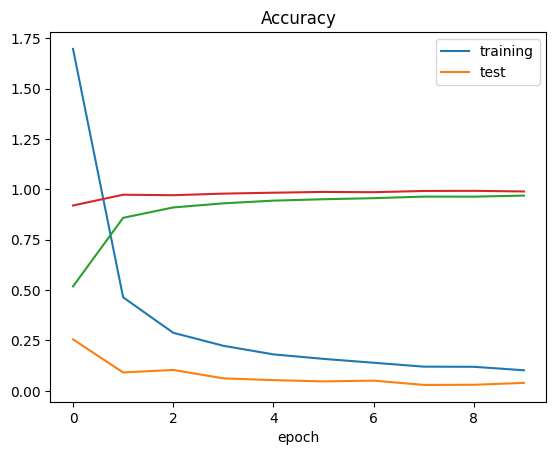

In [403]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('epoch')

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training','test'])
plt.title('Accuracy')
plt.xlabel('epoch')

#Evaluate model on test data
score = model.evaluate(X_test, y_test, verbose=0)
print('Test score:', score[0])
print('Test accuracy:', score[1])

(np.float64(-0.5), np.float64(1299.5), np.float64(945.5), np.float64(-0.5))

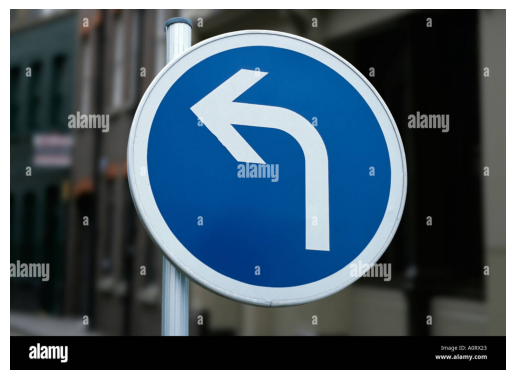

In [404]:
#predict internet number
import requests
from PIL import Image
url = 'https://c8.alamy.com/comp/A0RX23/cars-and-automobiles-must-turn-left-ahead-sign-A0RX23.jpg'
r = requests.get(url, stream=True)
img = Image.open(r.raw)
plt.imshow(img, cmap='gray')
plt.axis('off')

(32, 32)


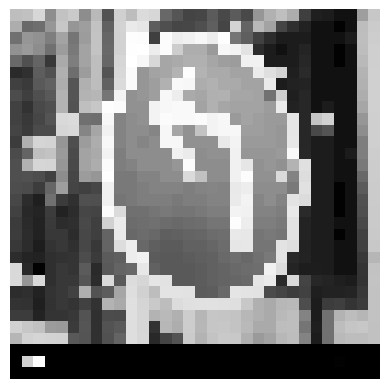

In [405]:
img = np.asarray(img)
img = cv2.resize(img, (32, 32))
img = preprocess(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
print(img.shape)

In [406]:
img = img.reshape(1, 32, 32, 1)
print("predicted sign: "+ str(model.predict(img)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
predicted sign: [[1.3258913e-14 1.1271400e-07 3.8582943e-03 7.5285477e-08 9.7259402e-11
  6.8416193e-05 1.5881512e-16 9.7352533e-08 3.4479593e-11 5.4066609e-09
  5.1592224e-08 2.5196815e-07 1.8519556e-04 2.4109334e-10 1.5334862e-09
  5.0183665e-08 1.5021380e-12 2.2325069e-06 1.9394076e-12 7.1559733e-12
  8.8891144e-10 7.0545210e-09 3.3270442e-08 9.2390562e-10 1.8941499e-11
  4.2707139e-08 7.3109704e-13 1.3076976e-14 3.0854916e-09 1.1195936e-07
  1.6594500e-05 6.3116989e-10 5.6015583e-14 2.8622502e-11 2.9443097e-01
  2.0934204e-02 6.5640247e-06 1.3561322e-06 6.7749709e-01 1.2635973e-10
  2.9982517e-03 2.6668062e-15 3.6660289e-12]]
